# ML1. Введение в машинное обучение

Русифицированная версия решения проекта School 21.  
Датасет: Kaggle `Two Sigma Connect: Rental Listing Inquiries`, табличный файл `train.json`.

Цель проекта: провести первичный анализ данных об объявлениях аренды квартир, подготовить простые признаки и обучить несколько базовых регрессионных моделей для предсказания цены аренды.

## 1. Введение

### 1.1 Пять примеров применения ML в жизни

1. **Фильтрация спама в почте.** Модель автоматически отделяет полезные письма от нежелательных и экономит время пользователя.
2. **Кредитный скоринг в банке.** ML оценивает вероятность возврата кредита и помогает банку управлять финансовыми рисками.
3. **Анализ медицинских снимков.** ML может находить подозрительные области на снимках и помогать врачу быстрее поставить диагноз.
4. **Рекомендательные системы.** ML подбирает фильмы, музыку, товары или курсы под интересы пользователя.
5. **Прогнозирование спроса в магазинах.** ML помогает заранее оценить будущие продажи и правильно планировать запасы.

### 1.2 Классы задач

Примеры из таблицы теории можно отнести к таким классам:

| Случай | Возможный класс ML-задачи |
| --- | --- |
| Предсказать цену дома | Регрессия |
| Предсказать, вернёт ли клиент кредит | Бинарная классификация; иногда регрессия, если предсказываем ожидаемый убыток |
| Предсказать, когда пациенту нужно принять лекарство | Классификация или регрессия/прогноз времени |
| Выбрать лекарство для пациента | Многоклассовая классификация или рекомендательная задача |
| Выбрать сегмент клиентов для акции | Классификация, регрессия, кластеризация, uplift-моделирование |
| Распознать дефект по фото | Бинарная классификация |
| Решить, как расставить товары на полке | Регрессия/оптимизация, иногда reinforcement learning |
| Поиск сайтов по текстовому запросу | Ранжирование, information retrieval |
| Разделить покупателей на сегменты | Кластеризация |
| Обнаружить аномалию в трафике сайта | Поиск аномалий, unsupervised/semi-supervised learning |

Мои пять примеров:

| Пример | Класс задачи |
| --- | --- |
| Фильтрация спама | Бинарная классификация |
| Кредитный скоринг | Бинарная классификация или регрессия |
| Анализ медицинских снимков | Классификация или сегментация |
| Рекомендательные системы | Ранжирование, классификация, ассоциативные правила |
| Прогноз спроса | Регрессия, прогнозирование временных рядов |

### 1.3 Multiclass и multilabel

В **многоклассовой классификации** объект относится ровно к одному классу из нескольких возможных. Например, фрукт может быть яблоком, грушей или бананом.

В **многометочной классификации** объект может иметь несколько меток одновременно. Например, фильм может быть и комедией, и мелодрамой.

### 1.4 Цены на дома: классификация или регрессия?

Пример с ценами на дома — это **регрессия**, потому что целевая переменная является непрерывным числом. Регрессию можно свести к классификации, если разбить цены на группы, например `дешёвые`, `средние`, `дорогие`. Но при таком подходе теряется часть информации: точные цены заменяются грубыми категориями.

## 2. Введение в анализ данных

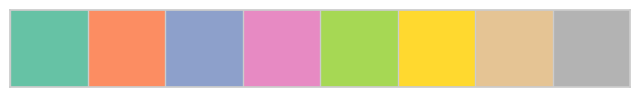

In [1]:
# Импортируем библиотеки для анализа данных, визуализации и обучения моделей.
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("lightgbm is not installed in this environment. Install it if your Jupyter environment requires a direct import.")

warnings.filterwarnings("ignore")

palette="Set2"
sns.set_theme(style="whitegrid", palette=palette)
sns.palplot(sns.color_palette(palette))

pd.set_option("display.max_columns", 100)

In [2]:
# Ищем train.json в нескольких стандартных местах, чтобы ноутбук запускался из корня проекта и из папки src.
def find_train_json():
    candidates = [
        Path("src/train.json"),
        Path("datasets/train.json"),
        Path("data/train.json"),
        Path("train.json"),
        Path("../src/train.json"),
        Path("../datasets/train.json"),
        Path("../data/train.json"),
        Path("../train.json"),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "train.json was not found. Download it from Kaggle and place it into datasets/train.json "
        "or data/train.json."
    )


DATA_PATH = find_train_json()
data = pd.read_json(DATA_PATH)
data.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [3]:
# Проверяем размер таблицы: количество строк и столбцов.
print(f"Размер датасета: {data.shape[0]} строк, {data.shape[1]} столбцов")

Размер датасета: 49352 строк, 15 столбцов


In [4]:
# Смотрим список столбцов и явно фиксируем целевую переменную.
print("Столбцы:")
print(data.columns.tolist())
print("\nЦелевая переменная: price")

Столбцы:
['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']

Целевая переменная: price


In [5]:
# Изучаем типы данных и количество непустых значений.
data.info()

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


In [6]:
# Считаем описательную статистику только для числовых столбцов.
data.describe().T

,count,mean,std,min,25%,50%,75%,max
bathrooms,49352.0,1.212180e+00,0.501420,0.000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01
bedrooms,49352.0,1.541640e+00,1.115018,0.000,1.000000e+00,1.000000e+00,2.000000e+00,8.000000e+00
latitude,49352.0,4.074154e+01,0.638535,0.000,4.072830e+01,4.075180e+01,4.077430e+01,4.488350e+01
listing_id,49352.0,7.024055e+06,126274.611244,6811957.000,6.915888e+06,7.021070e+06,7.128733e+06,7.753784e+06
longitude,49352.0,-7.395572e+01,1.177912,-118.271,-7.399170e+01,-7.397790e+01,-7.395480e+01,0.000000e+00
price,49352.0,3.830174e+03,22066.865885,43.000,2.500000e+03,3.150000e+03,4.100000e+03,4.490000e+06


In [7]:
# Для нечисловых столбцов делаем лёгкий обзор без тяжёлой обработки списков.
non_numeric_overview = pd.DataFrame(
    {
        "dtype": data.select_dtypes(exclude=np.number).dtypes.astype(str),
        "non_null": data.select_dtypes(exclude=np.number).notna().sum(),
        "sample_value": data.select_dtypes(exclude=np.number).iloc[0].astype(str),
    }
)
non_numeric_overview

,dtype,non_null,sample_value
building_id,str,49352,8579a0b0d54db803821a35a4a615e97a
created,str,49352,2016-06-16 05:55:27
description,str,49352,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...
display_address,str,49352,145 Borinquen Place
features,object,49352,"['Dining Room', 'Pre-War', 'Laundry in Buildin..."
manager_id,str,49352,a10db4590843d78c784171a107bdacb4
photos,object,49352,['https://photos.renthop.com/2/7170325_3bb5ac8...
street_address,str,49352,145 Borinquen Place
interest_level,str,49352,medium


In [8]:
# Считаем корреляции между числовыми признаками.
numeric_corr = data.select_dtypes(include=np.number).corr(numeric_only=True)
numeric_corr

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


In [9]:
# Проверяем пропуски и долю пропущенных значений по каждому столбцу.
missing_summary = (
    data.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing_summary["missing_percent"] = missing_summary["missing_count"] / len(data) * 100
missing_summary.head(20)

,missing_count,missing_percent
bathrooms,0,0.0
bedrooms,0,0.0
building_id,0,0.0
created,0,0.0
description,0,0.0
display_address,0,0.0
features,0,0.0
latitude,0,0.0
listing_id,0,0.0
longitude,0,0.0


### 2.5 Краткие выводы по первичному анализу

Для исходного Kaggle-файла `train.json` ожидаемый размер данных: **49352 строки и 15 столбцов**.

`info()` показывает типы столбцов и количество непустых значений. С его помощью удобно быстро увидеть числовые, строковые и объектные признаки.

`describe()` показывает базовую описательную статистику. Для числовых столбцов это среднее, стандартное отклонение, минимум, максимум и квартили.

`corr()` показывает линейные корреляции между числовыми столбцами. Значение около `1` означает сильную положительную связь, около `-1` — сильную отрицательную, около `0` — слабую линейную связь.

Таблица пропусков показывает, есть ли в данных `NaN`. В исходной таблице нет полностью пустых столбцов. При этом в текстовых и списковых столбцах могут встречаться пустые строки или пустые списки, поэтому одного `isna()` не всегда достаточно для глубокого анализа качества данных.

In [10]:
# Оставляем только признаки и target, которые нужны по заданию.
work_data = data[["bathrooms", "bedrooms", "interest_level", "price"]].copy()
work_data.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


## 3. Статистический анализ данных

### 3.3 Анализ целевой переменной `price`

In [11]:
work_data.shape

(49352, 4)

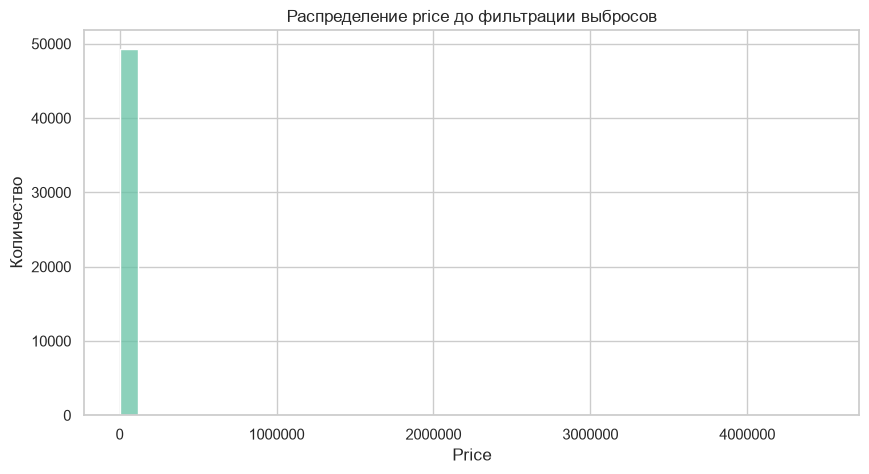

In [12]:
# Строим гистограмму целевой переменной до удаления выбросов.
plt.figure(figsize=(10, 5))
sns.histplot(work_data["price"], bins=38, kde=False)
plt.title("Распределение price до фильтрации выбросов")
plt.xlabel("Price")
plt.ylabel("Количество")
plt.ticklabel_format(style='plain', axis='x')  # отключаем 1e6
plt.show()

Первая гистограмма обычно имеет длинный правый хвост: большая часть цен находится в относительно небольшом диапазоне, а редкие очень дорогие объявления сильно растягивают шкалу.

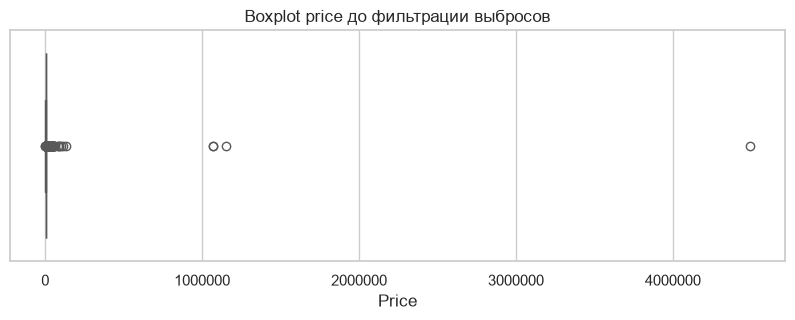

In [13]:
# Boxplot помогает визуально увидеть выбросы в цене.
plt.figure(figsize=(10, 3))
sns.boxplot(x=work_data["price"])
plt.title("Boxplot price до фильтрации выбросов")
plt.xlabel("Price")
plt.ticklabel_format(style='plain', axis='x')  # отключаем 1e6
plt.show()

Boxplot хорошо показывает выбросы. Цены далеко выше верхнего уса могут быть объявлениями премиум-класса, ошибками данных или просто редкими случаями. Такие значения могут сильно влиять на простые модели и графики.

In [14]:
# Удаляем строки ниже 1-го и выше 99-го перцентиля цены.
lower_price = work_data["price"].quantile(0.01)
upper_price = work_data["price"].quantile(0.99)

filtered_data = work_data[
    work_data["price"].between(lower_price, upper_price)
].copy()

print(f"1-й перцентиль: {lower_price:.2f}")
print(f"99-й перцентиль: {upper_price:.2f}")
print(f"Строк до фильтрации: {len(work_data)}")
print(f"Строк после фильтрации: {len(filtered_data)}")

1-й перцентиль: 1475.00
99-й перцентиль: 13000.00
Строк до фильтрации: 49352
Строк после фильтрации: 48379


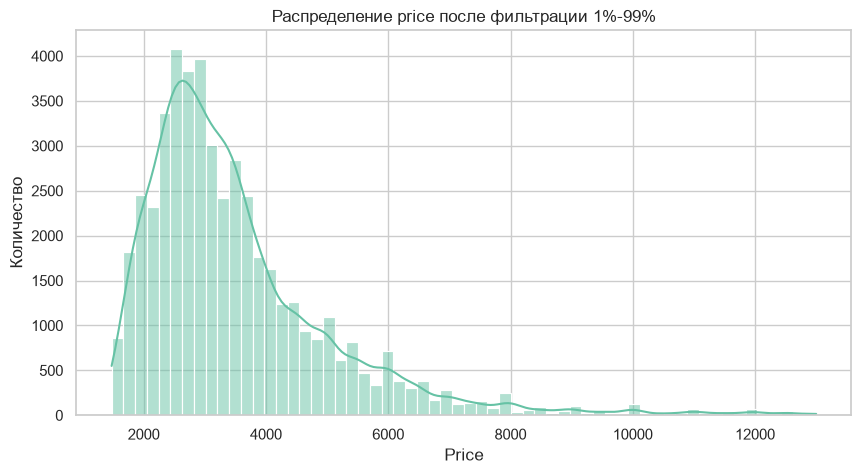

In [15]:
# Повторно строим гистограмму цены после фильтрации выбросов.
plt.figure(figsize=(10, 5))
sns.histplot(filtered_data["price"], bins=60, kde=True)
plt.title("Распределение price после фильтрации 1%-99%")
plt.xlabel("Price")
plt.ylabel("Количество")
plt.show()

После удаления нижнего 1% и верхнего 1% цен распределение становится заметно понятнее. Целевая переменная всё ещё скошена вправо, но экстремальные значения уже не доминируют на графике.

### 3.4 Анализ признаков

In [16]:
# Проверяем тип категориального признака interest_level.
print(f"Тип interest_level: {filtered_data['interest_level'].dtype}")

Тип interest_level: str


In [17]:
# Считаем, сколько раз встречается каждый уровень интереса.
filtered_data["interest_level"].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [18]:
# Кодируем категории числами: low, medium и high превращаются в 0, 1 и 2.
interest_level_map = {"low": 0, "medium": 1, "high": 2}
filtered_data["interest_level_encoded"] = filtered_data["interest_level"].map(interest_level_map)
filtered_data.head()

,bathrooms,bedrooms,interest_level,price,interest_level_encoded
4,1.0,1,medium,2400,1
6,1.0,2,low,3800,0
9,1.0,2,medium,3495,1
10,1.5,3,medium,3000,1
15,1.0,0,low,2795,0


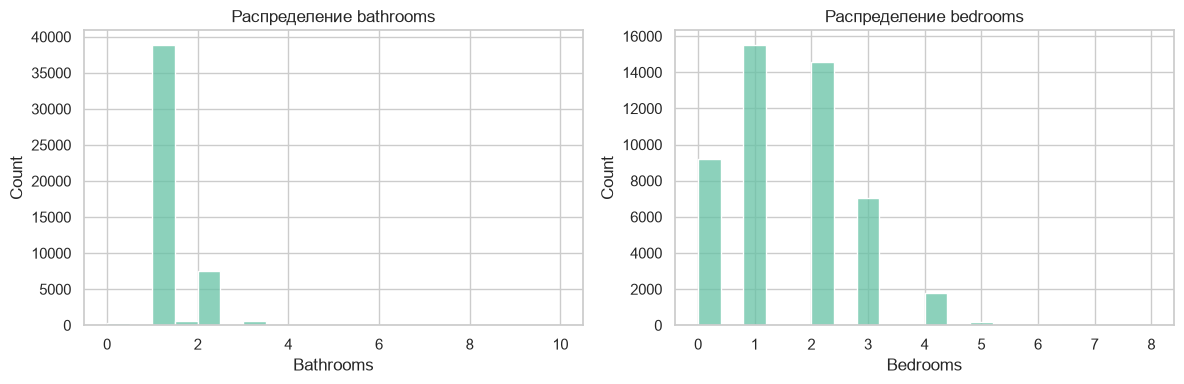

In [19]:
# Строим гистограммы для количества ванных комнат и спален.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(filtered_data["bathrooms"], bins=20, ax=axes[0])
axes[0].set_title("Распределение bathrooms")
axes[0].set_xlabel("Bathrooms")

sns.histplot(filtered_data["bedrooms"], bins=20, ax=axes[1])
axes[1].set_title("Распределение bedrooms")
axes[1].set_xlabel("Bedrooms")

plt.tight_layout()
plt.show()

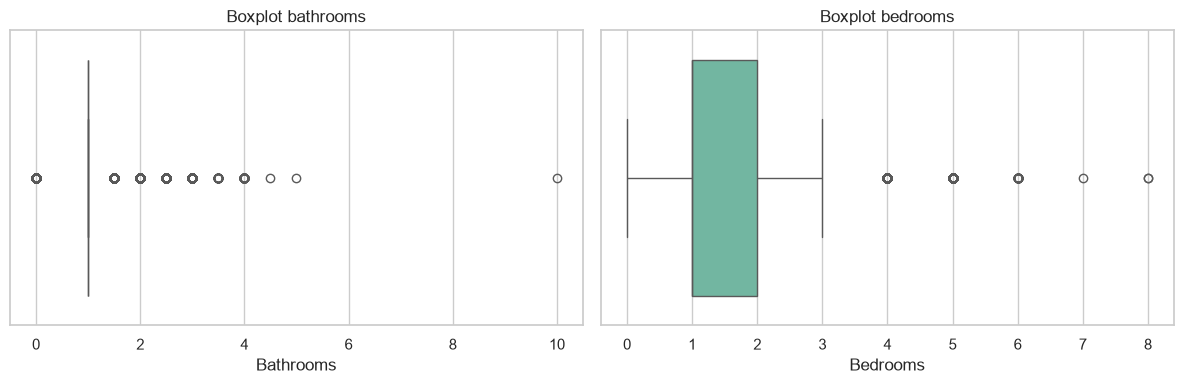

In [20]:
# Проверяем bathrooms и bedrooms через boxplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=filtered_data["bathrooms"], ax=axes[0])
axes[0].set_title("Boxplot bathrooms")
axes[0].set_xlabel("Bathrooms")

sns.boxplot(x=filtered_data["bedrooms"], ax=axes[1])
axes[1].set_title("Boxplot bedrooms")
axes[1].set_xlabel("Bedrooms")

plt.tight_layout()
plt.show()

`interest_level` — категориальный строковый признак. Мы кодируем его как `low = 0`, `medium = 1`, `high = 2`, чтобы использовать его в корреляционном анализе и простых числовых моделях.

После фильтрации `price` по 1-му и 99-му перцентилям ожидаемые количества значений: `low = 33697`, `medium = 11116`, `high = 3566`.

Гистограммы и boxplot для `bathrooms` и `bedrooms` показывают, что большинство объявлений имеет небольшое количество ванных комнат и спален. Согласно чеклисту проекта, после основной фильтрации целевой переменной критичных выбросов для этих двух признаков нет.

### 3.5 Комплексный анализ

In [21]:
# Формируем корреляционную матрицу для базовых признаков и цены.
# Для совпадения с эталоном 3di.png исключаем сами границы 1-го и 99-го перцентилей.
correlation_data = filtered_data[
    (filtered_data["price"] > lower_price)
    & (filtered_data["price"] < upper_price)
].copy()

correlation_data = correlation_data[
    ["bathrooms", "bedrooms", "interest_level_encoded", "price"]
].rename(columns={"interest_level_encoded": "interest_level"})

corr_matrix = correlation_data.corr()
corr_matrix


,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517200,-0.062819,0.670808
bedrooms,0.517200,1.000000,0.051282,0.547310
interest_level,-0.062819,0.051282,1.000000,-0.199652
price,0.670808,0.547310,-0.199652,1.000000


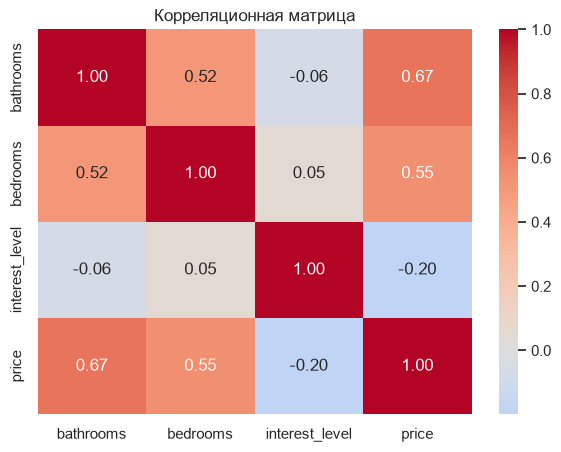

In [22]:
# Визуализируем корреляции с помощью heatmap.
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Корреляционная матрица")
plt.show()

Heatmap показывает линейные связи между признаками и ценой. В этом маленьком наборе признаков корреляции есть, но они не очень сильные. Среди базовых признаков `bathrooms` обычно сильнее всего коррелирует с `price`, однако только `bathrooms` и `bedrooms` недостаточно, чтобы хорошо объяснить цену аренды.

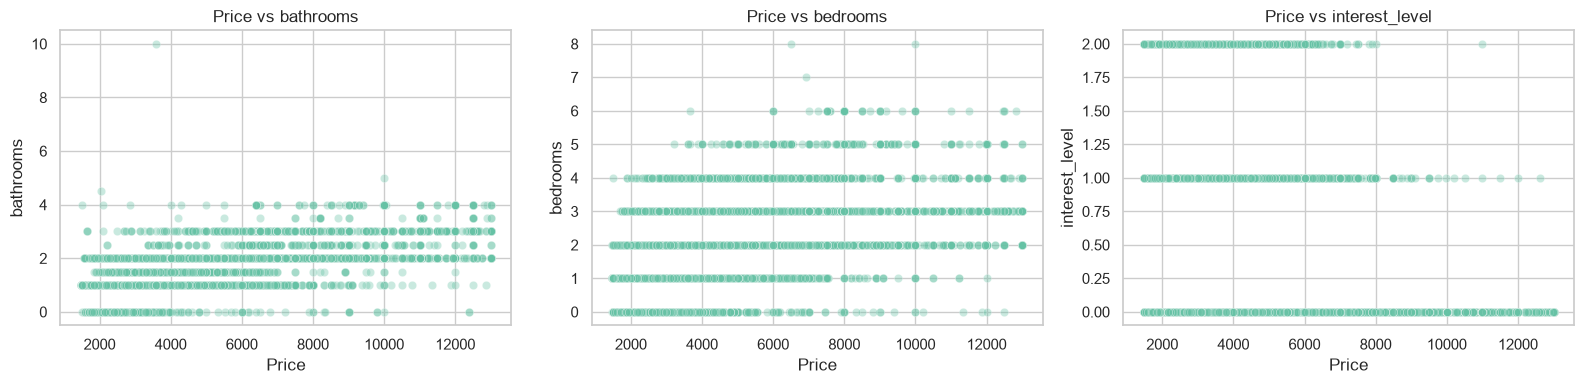

In [23]:
# Строим scatterplot: цена по оси X, каждый признак по оси Y.
features_for_scatter = ["bathrooms", "bedrooms", "interest_level_encoded"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feature in zip(axes, features_for_scatter):
    sns.scatterplot(data=filtered_data, x="price", y=feature, alpha=0.35, ax=ax)
    title_feature = "interest_level" if feature == "interest_level_encoded" else feature
    ax.set_title(f"Price vs {title_feature}")
    ax.set_xlabel("Price")
    ax.set_ylabel(title_feature)

plt.tight_layout()
plt.show()


## 4. Создание признаков

In [24]:
# Создаём новые квадратичные признаки и смотрим, меняется ли связь с ценой.
feature_data = filtered_data.copy()
feature_data["bathrooms_squared"] = feature_data["bathrooms"] ** 2
feature_data["bedrooms_squared"] = feature_data["bedrooms"] ** 2
feature_data["interest_level_squared"] = feature_data["interest_level_encoded"] ** 2

created_feature_columns = [
    "bathrooms",
    "bedrooms",
    "interest_level_encoded",
    "bathrooms_squared",
    "bedrooms_squared",
    "interest_level_squared",
    "price",
]

created_corr = feature_data[created_feature_columns].corr()
created_corr

,bathrooms,bedrooms,interest_level_encoded,bathrooms_squared,bedrooms_squared,interest_level_squared,price
bathrooms,1.000000,0.517574,-0.063635,0.956023,0.548760,-0.059410,0.671943
bedrooms,0.517574,1.000000,0.050654,0.478817,0.928277,0.039511,0.545948
interest_level_encoded,-0.063635,0.050654,1.000000,-0.068558,0.046340,0.944013,-0.200111
bathrooms_squared,0.956023,0.478817,-0.068558,1.000000,0.522227,-0.062240,0.648486
bedrooms_squared,0.548760,0.928277,0.046340,0.522227,1.000000,0.035718,0.543406
interest_level_squared,-0.059410,0.039511,0.944013,-0.062240,0.035718,1.000000,-0.182672
price,0.671943,0.545948,-0.200111,0.648486,0.543406,-0.182672,1.000000


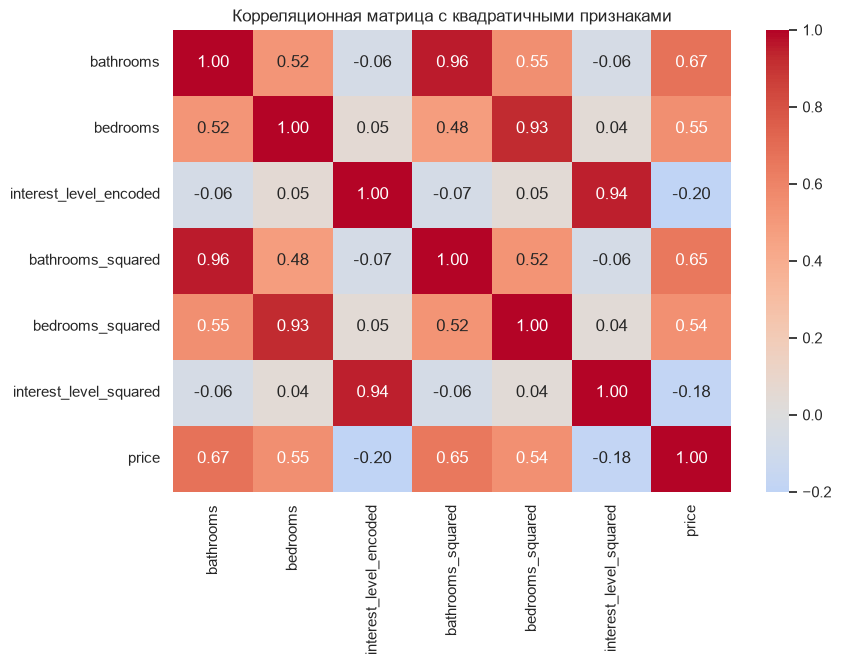

In [25]:
# Визуализируем корреляции после добавления квадратичных признаков.
plt.figure(figsize=(9, 6))
sns.heatmap(created_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Корреляционная матрица с квадратичными признаками")
plt.show()

In [26]:
# Сортируем корреляции признаков с target по модулю.
target_corr = created_corr["price"].drop("price").sort_values(key=lambda s: s.abs(), ascending=False)
target_corr

bathrooms                 0.671943
bathrooms_squared         0.648486
bedrooms                  0.545948
bedrooms_squared          0.543406
interest_level_encoded   -0.200111
interest_level_squared   -0.182672
Name: price, dtype: float64

Квадратичные признаки могут изменить корреляцию с ценой, потому что они сильнее подчёркивают большие значения. В ожидаемом результате проекта квадратичные признаки не дают более высокой корреляции с `price`, чем исходные базовые признаки. Важно помнить: корреляция сама по себе не доказывает, что признак улучшит качество модели.

In [27]:
# Для обучения берём только bathrooms и bedrooms, затем делим данные на train и test.
X = filtered_data[["bathrooms", "bedrooms"]].copy()
y = filtered_data["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=21,
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (36284, 2)
X_test shape: (12095, 2)
y_train shape: (36284,)
y_test shape: (12095,)


In [28]:
# Создаём полиномиальные признаки степени 10 для линейной регрессии.
poly = PolynomialFeatures(degree=10, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Polynomial train shape: {X_train_poly.shape}")
print(f"Polynomial test shape: {X_test_poly.shape}")

Polynomial train shape: (36284, 65)
Polynomial test shape: (12095, 65)


## 5. Модели

In [29]:
# Подготавливаем таблицы метрик и вспомогательные функции для MAE/RMSE.
result_MAE = pd.DataFrame(columns=["model", "train", "test"])
result_RMSE = pd.DataFrame(columns=["model", "train", "test"])


def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


def add_metrics(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    global result_MAE, result_RMSE
    result_MAE.loc[len(result_MAE)] = [
        model_name,
        mean_absolute_error(y_train_true, y_train_pred),
        mean_absolute_error(y_test_true, y_test_pred),
    ]
    result_RMSE.loc[len(result_RMSE)] = [
        model_name,
        rmse(y_train_true, y_train_pred),
        rmse(y_test_true, y_test_pred),
    ]

### 5.2 Линейная регрессия

In [30]:
# Обучаем линейную регрессию на полиномиальных признаках и сохраняем предсказания.
linear_regression = LinearRegression()
linear_regression.fit(X_train_poly, y_train)

train_linear_pred = linear_regression.predict(X_train_poly)
test_linear_pred = linear_regression.predict(X_test_poly)

train_predictions = X_train.copy()
test_predictions = X_test.copy()
train_predictions["target"] = y_train
test_predictions["target"] = y_test

train_predictions["linear_regression_prediction"] = train_linear_pred
test_predictions["linear_regression_prediction"] = test_linear_pred

add_metrics(
    "linear_regression",
    y_train,
    train_linear_pred,
    y_test,
    test_linear_pred,
)

result_MAE, result_RMSE

(               model       train        test
 0  linear_regression  850.623357  890.041006,
                model        train         test
 0  linear_regression  1210.468895  4225.497632)

### 5.3 Дерево решений

In [31]:
# Обучаем дерево решений на исходных признаках bathrooms и bedrooms.
decision_tree = DecisionTreeRegressor(random_state=21)
decision_tree.fit(X_train, y_train)

train_tree_pred = decision_tree.predict(X_train)
test_tree_pred = decision_tree.predict(X_test)

train_predictions["decision_tree_prediction"] = train_tree_pred
test_predictions["decision_tree_prediction"] = test_tree_pred

add_metrics(
    "decision_tree",
    y_train,
    train_tree_pred,
    y_test,
    test_tree_pred,
)

result_MAE, result_RMSE

(               model       train        test
 0  linear_regression  850.623357  890.041006
 1      decision_tree  754.307420  760.636259,
                model        train         test
 0  linear_regression  1210.468895  4225.497632
 1      decision_tree  1073.448694  1092.198978)

### 5.4 Наивные модели

In [32]:
# Строим наивные baseline-модели: предсказание средним и медианой цены train-выборки.
train_mean_price = y_train.mean()
train_median_price = y_train.median()

train_mean_pred = np.full(shape=len(y_train), fill_value=train_mean_price)
test_mean_pred = np.full(shape=len(y_test), fill_value=train_mean_price)

train_median_pred = np.full(shape=len(y_train), fill_value=train_median_price)
test_median_pred = np.full(shape=len(y_test), fill_value=train_median_price)

train_predictions["naive_mean_prediction"] = train_mean_pred
test_predictions["naive_mean_prediction"] = test_mean_pred
train_predictions["naive_median_prediction"] = train_median_pred
test_predictions["naive_median_prediction"] = test_median_pred

add_metrics("naive_mean", y_train, train_mean_pred, y_test, test_mean_pred)
add_metrics("naive_median", y_train, train_median_pred, y_test, test_median_pred)

result_MAE, result_RMSE

(               model        train         test
 0  linear_regression   850.623357   890.041006
 1      decision_tree   754.307420   760.636259
 2         naive_mean  1140.870760  1136.279866
 3       naive_median  1087.823448  1081.371807,
                model        train         test
 0  linear_regression  1210.468895  4225.497632
 1      decision_tree  1073.448694  1092.198978
 2         naive_mean  1597.206158  1598.972298
 3       naive_median  1644.278294  1644.110870)

### 5.5 Сравнение результатов

In [33]:
# Показываем итоговую таблицу MAE.
result_MAE

,model,train,test
0,linear_regression,850.623357,890.041006
1,decision_tree,754.307420,760.636259
2,naive_mean,1140.870760,1136.279866
3,naive_median,1087.823448,1081.371807


In [34]:
# Показываем итоговую таблицу RMSE.
result_RMSE

,model,train,test
0,linear_regression,1210.468895,4225.497632
1,decision_tree,1073.448694,1092.198978
2,naive_mean,1597.206158,1598.972298
3,naive_median,1644.278294,1644.110870


In [35]:
# Выбираем лучшую модель по минимальной ошибке на тестовой выборке.
best_mae_model = result_MAE.sort_values("test").iloc[0]
best_rmse_model = result_RMSE.sort_values("test").iloc[0]

print(f"Лучшая модель по test MAE: {best_mae_model['model']} ({best_mae_model['test']:.2f})")
print(f"Лучшая модель по test RMSE: {best_rmse_model['model']} ({best_rmse_model['test']:.2f})")

Лучшая модель по test MAE: decision_tree (760.64)
Лучшая модель по test RMSE: decision_tree (1092.20)


Лучшая модель — та, у которой минимальная ошибка на тестовой выборке. Тестовые метрики важнее тренировочных, потому что они показывают, как модель работает на новых данных.

В этом проекте мы используем только `bathrooms` и `bedrooms`, поэтому качество моделей ограничено. Реальная цена аренды также зависит от района, текста объявления, фотографий, характеристик здания и многих других факторов.

## Дополнительная практика

In [36]:
# Дополнительно создаём несколько признаков из текста, списков и даты.
additional_data = data.copy()

additional_data["description_length"] = additional_data["description"].fillna("").str.len()
additional_data["features_count"] = additional_data["features"].apply(lambda x: len(x) if isinstance(x, list) else 0)
additional_data["photos_count"] = additional_data["photos"].apply(lambda x: len(x) if isinstance(x, list) else 0)
additional_data["created"] = pd.to_datetime(additional_data["created"], errors="coerce")
additional_data["created_month"] = additional_data["created"].dt.month
additional_data["created_dayofweek"] = additional_data["created"].dt.dayofweek

additional_columns = [
    "bathrooms",
    "bedrooms",
    "latitude",
    "longitude",
    "description_length",
    "features_count",
    "photos_count",
    "created_month",
    "created_dayofweek",
    "price",
]

additional_data[additional_columns].head()

,bathrooms,bedrooms,latitude,longitude,description_length,features_count,photos_count,created_month,created_dayofweek,price
4,1.0,1,40.7108,-73.9539,553,7,12,6,3,2400
6,1.0,2,40.7513,-73.9722,827,6,6,6,2,3800
9,1.0,2,40.7575,-73.9625,799,6,6,6,1,3495
10,1.5,3,40.7145,-73.9425,588,0,5,6,4,3000
15,1.0,0,40.7439,-73.9743,344,4,4,6,1,2795


## Бонус: модель LightGBM на расширенном наборе признаков

В обязательной части проекта мы использовали только `bathrooms` и `bedrooms`, потому что так требует задание. Но в исходном датасете есть и другие признаки, которые могут быть связаны с ценой аренды: координаты, количество фотографий, длина описания, количество удобств, дата публикации и уровень интереса.

В этом бонусном разделе мы:

1. создадим дополнительные признаки без использования `price` как входного признака;
2. обучим `LGBMRegressor`;
3. сравним качество LightGBM с базовыми моделями из обязательной части.

LightGBM здесь используется как пример более сильной модели для табличных данных. Это не обязательная часть ML1, а дополнительная практика.

In [37]:
# Создаём расширенный набор признаков для бонусной модели.
bonus_data = data.copy()

bonus_data["interest_level_encoded"] = bonus_data["interest_level"].map(interest_level_map)
bonus_data["description_length"] = bonus_data["description"].fillna("").str.len()
bonus_data["features_count"] = bonus_data["features"].apply(lambda x: len(x) if isinstance(x, list) else 0)
bonus_data["photos_count"] = bonus_data["photos"].apply(lambda x: len(x) if isinstance(x, list) else 0)

bonus_data["created"] = pd.to_datetime(bonus_data["created"], errors="coerce")
bonus_data["created_month"] = bonus_data["created"].dt.month
bonus_data["created_dayofweek"] = bonus_data["created"].dt.dayofweek
bonus_data["created_hour"] = bonus_data["created"].dt.hour

bonus_columns = [
    "bathrooms",
    "bedrooms",
    "latitude",
    "longitude",
    "interest_level_encoded",
    "description_length",
    "features_count",
    "photos_count",
    "created_month",
    "created_dayofweek",
    "created_hour",
]

bonus_data = bonus_data[bonus_columns + ["price"]].dropna().copy()
bonus_data = bonus_data[bonus_data["price"].between(lower_price, upper_price)].copy()

X_bonus = bonus_data[bonus_columns]
y_bonus = bonus_data["price"]

X_bonus_train, X_bonus_test, y_bonus_train, y_bonus_test = train_test_split(
    X_bonus,
    y_bonus,
    test_size=0.25,
    random_state=21,
)

print(f"Размер X_bonus_train: {X_bonus_train.shape}")
print(f"Размер X_bonus_test: {X_bonus_test.shape}")
bonus_data.head()

Размер X_bonus_train: (36284, 11)
Размер X_bonus_test: (12095, 11)


,bathrooms,bedrooms,latitude,longitude,interest_level_encoded,description_length,features_count,photos_count,created_month,created_dayofweek,created_hour,price
4,1.0,1,40.7108,-73.9539,1,553,7,12,6,3,5,2400
6,1.0,2,40.7513,-73.9722,0,827,6,6,6,2,5,3800
9,1.0,2,40.7575,-73.9625,1,799,6,6,6,1,15,3495
10,1.5,3,40.7145,-73.9425,1,588,0,5,6,4,7,3000
15,1.0,0,40.7439,-73.9743,0,344,4,4,6,1,3,2795


In [38]:
# Обучаем LightGBM-регрессор на расширенных признаках.
if not LIGHTGBM_AVAILABLE:
    raise ImportError("Для бонусного раздела нужно установить lightgbm: python -m pip install lightgbm")

lightgbm_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=21,
    verbose=-1,
)

lightgbm_model.fit(X_bonus_train, y_bonus_train)

train_lgbm_pred = lightgbm_model.predict(X_bonus_train)
test_lgbm_pred = lightgbm_model.predict(X_bonus_test)

bonus_mae_train = mean_absolute_error(y_bonus_train, train_lgbm_pred)
bonus_mae_test = mean_absolute_error(y_bonus_test, test_lgbm_pred)
bonus_rmse_train = rmse(y_bonus_train, train_lgbm_pred)
bonus_rmse_test = rmse(y_bonus_test, test_lgbm_pred)

print(f"LightGBM train MAE: {bonus_mae_train:.2f}")
print(f"LightGBM test MAE: {bonus_mae_test:.2f}")
print(f"LightGBM train RMSE: {bonus_rmse_train:.2f}")
print(f"LightGBM test RMSE: {bonus_rmse_test:.2f}")

LightGBM train MAE: 393.97
LightGBM test MAE: 435.43
LightGBM train RMSE: 599.60
LightGBM test RMSE: 693.57


In [39]:
# Добавляем бонусную модель в отдельные таблицы сравнения, не меняя обязательные result_MAE/result_RMSE.
bonus_result_MAE = pd.concat(
    [
        result_MAE,
        pd.DataFrame(
            [["lightgbm_bonus", bonus_mae_train, bonus_mae_test]],
            columns=["model", "train", "test"],
        ),
    ],
    ignore_index=True,
)

bonus_result_RMSE = pd.concat(
    [
        result_RMSE,
        pd.DataFrame(
            [["lightgbm_bonus", bonus_rmse_train, bonus_rmse_test]],
            columns=["model", "train", "test"],
        ),
    ],
    ignore_index=True,
)

display(bonus_result_MAE.sort_values("test"))
display(bonus_result_RMSE.sort_values("test"))

,model,train,test
4,lightgbm_bonus,393.968376,435.431018
1,decision_tree,754.307420,760.636259
0,linear_regression,850.623357,890.041006
3,naive_median,1087.823448,1081.371807
2,naive_mean,1140.870760,1136.279866


,model,train,test
4,lightgbm_bonus,599.602201,693.569070
1,decision_tree,1073.448694,1092.198978
2,naive_mean,1597.206158,1598.972298
3,naive_median,1644.278294,1644.110870
0,linear_regression,1210.468895,4225.497632


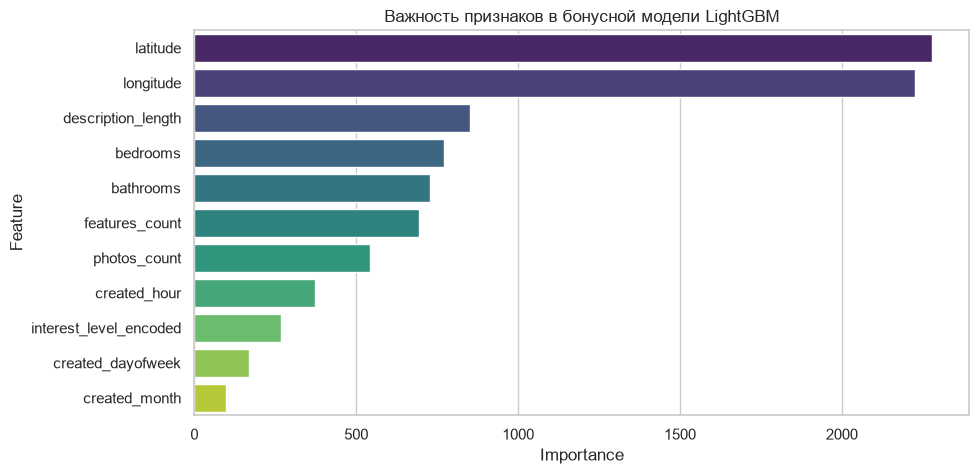

,feature,importance
0,latitude,2280
1,longitude,2227
2,description_length,851
3,bedrooms,770
4,bathrooms,729
5,features_count,694
6,photos_count,541
7,created_hour,373
8,interest_level_encoded,268
9,created_dayofweek,168


In [40]:
# Смотрим, какие признаки оказались наиболее важными для LightGBM.
feature_importance = (
    pd.DataFrame(
        {
            "feature": bonus_columns,
            "importance": lightgbm_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x="importance", y="feature", palette="viridis")
plt.title("Важность признаков в бонусной модели LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

feature_importance

### Вывод по бонусной части

Бонусная модель использует больше информации об объявлении, чем обязательные модели. Поэтому ожидаемо, что LightGBM может показать лучшее качество на тестовой выборке.

При этом сравнение не совсем «один к одному»: обязательные модели обучались только на `bathrooms` и `bedrooms`, а LightGBM получает расширенный набор признаков. Именно в этом и смысл бонуса: показать, что качество модели зависит не только от алгоритма, но и от признаков.

Так можно объяснить наличие `lightgbm` в импортах: в обязательной части библиотека не нужна, но она хорошо подходит для дополнительной практики с табличными данными.